# 🎓 Predicting Student Mental Health Score from Social Media Usage

**Problem:** We're predicting a student's `Mental_Health_Score` (a continuous score from ~3 to ~10) using their social media habits, study time, sleep, physical activity, and stress level. This is a **regression** problem since the target is a number, not a category.

**Dataset:** `Student_Social_Media_And_Mental_Health_Impact.csv` — 5,000 students, 13 columns covering demographics (Age, Gender, Country), platform usage (Avg_Daily_Usage_Hours, Daily_Unlocks, Most_Used_Platform), lifestyle (Study_Hours, Sleep_Hours_Per_Night, Physical_Activity_Hours), and Stress_Level.



## 1. Import Libraries

We're grouping imports by purpose: data handling, visualization, preprocessing, models, evaluation, and saving. Keeping imports grouped like this makes it easy to see at a glance what the notebook is going to do.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

We load the CSV and take a first look at its shape and the first few rows. This is always the very first step — you can't make any decisions about a dataset until you've actually looked at it.

In [ ]:
df = pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [ ]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [ ]:
  #Looking for number of rows and columns.
df.shape

(5000, 13)

In [ ]:
#Look at first 5 rows.
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


📌 **Reading this:** Zero duplicate rows. Nothing to remove here, but we always check — silently keeping duplicate rows can quietly bias a model toward whatever got repeated.

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [ ]:
df.duplicated().sum()

np.int64(2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [ ]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


📌 **Reading this:** Most columns look reasonable — but look closely at `Physical_Activity_Hours`: the **minimum value is -0.4**. Negative hours aren't physically possible, so this is a data-entry glitch, not a real value. We'll fix this properly in the **Data Cleaning** step below instead of ignoring it.

## 4. Exploratory Data Analysis (EDA)

We'll keep this focused — six plots, each answering one specific question about the data, not a wall of charts for the sake of it.

### 4.1 — Distribution of the target (`Mental_Health_Score`)

Before predicting anything, we need to understand the shape of what we're predicting.

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

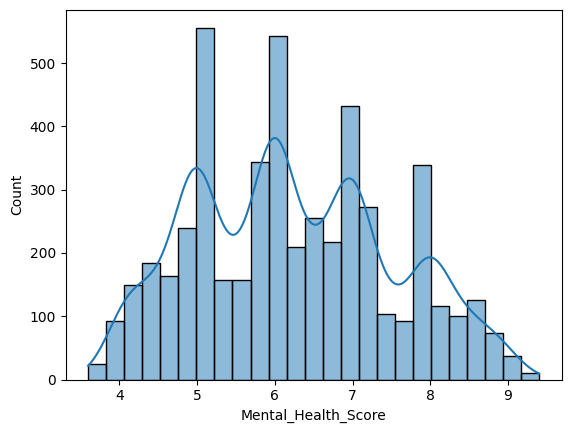

In [ ]:
sns.histplot(df['Mental_Health_Score'], kde=True)

### 4.2 — Correlation heatmap

Which numeric features actually move together with the target?

<Axes: >

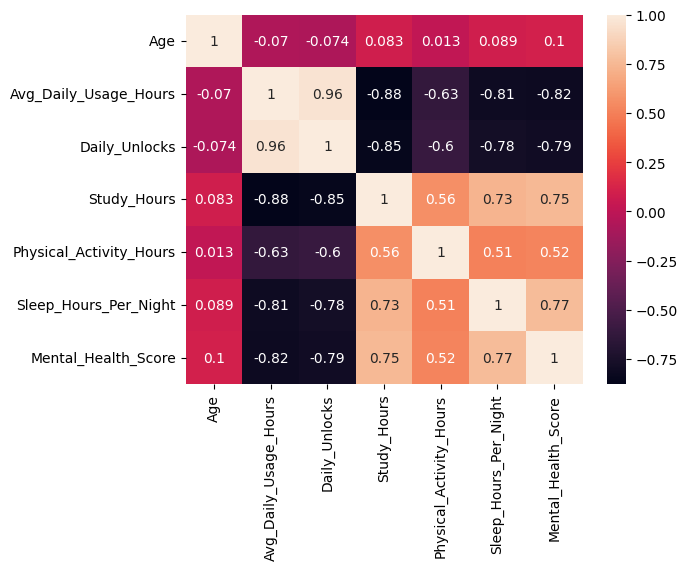

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

### 4.3 — Stress Level vs Mental Health Score

Does higher stress genuinely come with a lower score?

In [ ]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [ ]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

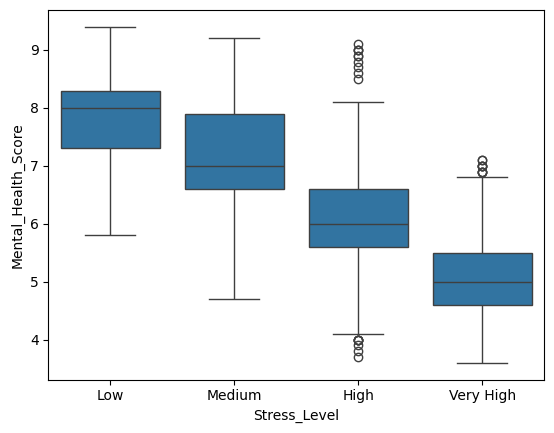

In [ ]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level', y='Mental_Health_Score',data=df, order=order)

### 4.4 — Daily Usage Hours vs Mental Health Score

Does more time on social media relate to a lower score?

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

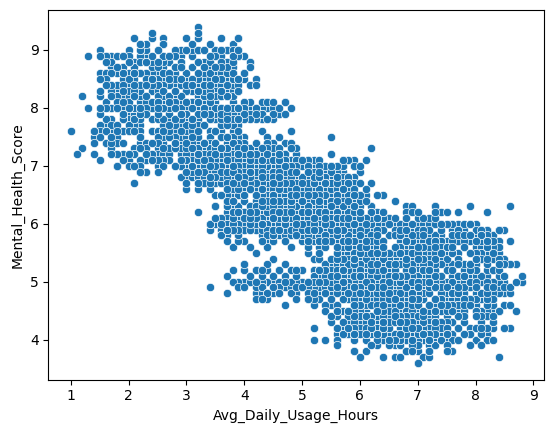

In [ ]:
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score',data=df)

### 4.5 — Sleep Hours vs Mental Health Score

Sleep is one of the most commonly cited mental health factors — does the data back that up?

In [ ]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

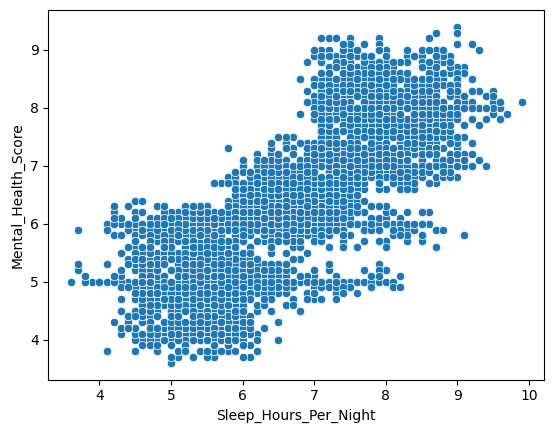

In [ ]:
sns.scatterplot(x='Sleep_Hours_Per_Night', y='Mental_Health_Score', data=df)

### 4.6 — Most Used Platform (count)

A quick look at which platforms are most common in our dataset.

In [ ]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [ ]:
df['Most_Used_Platform'].value_counts()

,count
Most_Used_Platform,
Instagram,1130
TikTok,918
Facebook,719
LinkedIn,523
YouTube,491
Twitter,462
Snapchat,420
WhatsApp,175
LINE,50


<Axes: xlabel='Most_Used_Platform', ylabel='count'>

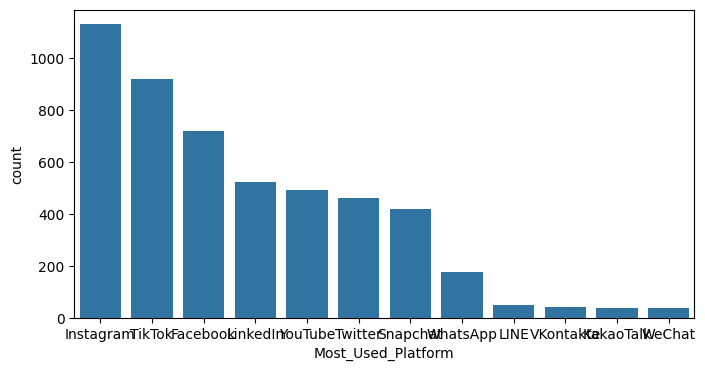

In [ ]:
plt.figure(figsize=(8, 4))
sns.countplot(x=df['Most_Used_Platform'], order=df['Most_Used_Platform'].value_counts().index)

**Checking Outliers**

In [ ]:
num_features = df.select_dtypes(include='number') #int64 or float64
Q1  = num_features.quantile(0.25)
Q3  = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


## 5. Data Cleaning

Two real issues to fix here — everything else in this dataset is already clean, so we don't manufacture cleaning steps that aren't needed.

In [ ]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [ ]:
#1. To drop duplicates
df = df.drop_duplicates()

#2. Converting negative or unrealitstic value to realistic value
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

📌 **Why `clip(lower=0)` and not dropping the row:** the rest of that student's data (age, study hours, stress level, etc.) is still valid and useful — throwing away the whole row over one bad value wastes good data. Clipping caps the impossible value at the nearest realistic one (0 hours) without discarding everything else about that student.

We're not dropping any columns either — every column here has a plausible reason to matter for predicting mental health, and we already confirmed none of them are empty or constant.

## 6. Skewness

**What skewness is:** a measure of how lopsided a numeric column's distribution is. A value near 0 means roughly symmetric (bell-shaped); a large positive or negative value means the data leans heavily to one side, with a long tail.

**Why it matters:** models like Linear Regression assume features are roughly well-behaved. A heavily skewed column (think: a long tail of extreme values) can quietly drag the model's predictions in that direction. Tree-based models like Random Forest don't care about skew — but since we're also training a Linear Regression baseline, it's worth fixing.

In [ ]:
num_cols = df.select_dtypes(include='number')
num_cols.skew()
# near to 0 -> Centralized (0.01, 0.002)
# negative -> Left Skewed (-1.56)
# poistive (greater than 0) -> Right Skewed (1.256)

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


## 7. Feature Engineering

**One meaningful engineered feature here:** grouping `Country`.

- `Country` has **111 unique values** in this dataset — one-hot encoding that directly would add 110+ mostly-empty columns, which hurts the model far more than it helps (this is called high cardinality).
- Dropping `Country` entirely throws away real signal — a student's country genuinely correlates with things like internet access, culture, and sleep norms.
- **The fix:** keep the top 10 most frequent countries as their own category, and bucket everything else into `"Other"`. We keep the signal that matters and lose the noise that doesn't.

In [ ]:
top_countries = df['Country'].value_counts().index[:10].tolist()

In [ ]:
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'

In [ ]:
df['Grouped_country'] = df['Country'].apply(group_countries)

In [ ]:
df['Grouped_country'].value_counts()

,count
Grouped_country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


📌 **Result:** we went from 111 raw categories down to 11 manageable ones (10 countries + "Other"). This is exactly the kind of decision that separates a project that "just ran `pd.get_dummies()`" from one that actually thought about the data.

## 8. Encoding Strategy

Before we jump into code, let's decide *how* each categorical column should be encoded — this decision matters more than the code itself.

- **`Stress_Level` → Ordinal Encoding.** Its categories have a real, meaningful order: Low < Medium < High < Very High. We already saw in EDA (section 4.3) that the score drops step by step as stress increases — encoding it as 0, 1, 2, 3 preserves that order for the model.
- **`Gender`, `Academic_Level`, `Most_Used_Platform`, `Purpose_Of_Use`, `Country_Grouped` → One-Hot Encoding.** These categories have **no natural order** — "Instagram" isn't "greater than" "LinkedIn". One-hot encoding creates a separate 0/1 column per category so the model doesn't accidentally assume a false ranking.

We'll implement both of these inside a single `ColumnTransformer` in the next step, rather than doing it manually column by column — that keeps preprocessing consistent and reusable.

## 9. Train-Test Split

**Why we split:** we need data the model has never seen to honestly check how well it generalizes. If we evaluate on the same data we trained on, the model can just "memorize" the answers and look artificially good.

**Common ratios:** 80/20 or 70/30 are both standard. We'll use an 80/20 split here — with 5,000 rows, that still leaves 1,000 rows for a solid, reliable test.

We split **before** fitting any preprocessing — this is the single most common beginner mistake (called data leakage), and we'll avoid it by fitting everything only on the training set.

In [ ]:
from sklearn.model_selection import train_test_split

skwewd_col         = ['Study_Hours']
other_numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours",
                      "Sleep_Hours_Per_Night"]
ordinal_col        = ['Stress_Level']
normal_col         = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped_country"]


feature_col = skwewd_col + other_numeric_cols + ordinal_col + normal_col
X = df[feature_col]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

## 10. Preprocessing using ColumnTransformer

Our columns need **different treatment**:

- `Study_Hours` (the skewed one) → impute → `log1p` transform → scale
- The other numeric columns → impute → scale (no skew to fix)
- `Stress_Level` → impute → `OrdinalEncoder` with an **explicit order**
- The nominal columns → impute → `OneHotEncoder`

We include a `SimpleImputer` in every branch even though this dataset has zero missing values right now — it's a safety net. Real-world data (and our future API's incoming requests) won't always be this clean, and a pipeline that assumes "no missing values ever" is a pipeline that breaks in production.

`ColumnTransformer` glues all of this into **one object** that applies the right transformation to the right column type in a single `.fit()` / `.transform()` call — no manual column-by-column juggling.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
#1. Skewed features
skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())

])

#2. Numeric Features
plain_numeric_pipeline = Pipeline(steps=[
    ('scale',StandardScaler())
])

#3. Ordinal
ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

#4. Nominal Features
nominal_pipeline = Pipeline(steps=[
    ('encode', OneHotEncoder(handle_unknown="ignore"))
])


    # (konsi_pipeline, konsa_feature)
preprocessor = ColumnTransformer(transformers=[
    ("Skewed_Pipeline", skew_pipeline, skwewd_col),
    ("Plain_Numeric",plain_numeric_pipeline, other_numeric_cols ),
    ('Ordinal', ordinal_pipeline, ordinal_col),
    ('Normal', nominal_pipeline, normal_col)
])



## 11. Build a Pipeline

**Why Pipeline matters:** a `Pipeline` chains preprocessing and the model into a single object. Calling `.fit()` once does both steps in the correct order, and calling `.predict()` on brand-new raw data automatically applies the exact same preprocessing that was used during training — no risk of forgetting a step or applying it inconsistently.

**Why companies prefer this:** when this model gets deployed (which we're doing in Part 2 with FastAPI), the API doesn't need to know *anything* about scaling, encoding, or log transforms — it just loads one saved pipeline object and calls `.predict()` on raw input. That's a huge reduction in what can go wrong in production.

We'll build two pipelines below — one per model — so we can fairly compare them.

## 12. Model Building

We're comparing **two models** here because the comparison itself teaches something useful — a plain Linear Regression baseline versus a Random Forest, which can capture the non-linear patterns we spotted back in EDA (section 4.4).

### 12.1 — Baseline: Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds       = lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)

lr_r2_testing  = r2_score(y_test, lr_preds)
lr_r2_training = r2_score(y_train, lr_preds_train)
lr_mae         = mean_absolute_error(y_test, lr_preds)

print(f"Accuracy of Training {lr_r2_training}")
print(f"Accuracy of Testing {lr_r2_testing}")
print(f'MAE {lr_mae}')

Accuracy of Training 0.7236771199387538
Accuracy of Testing 0.739794461743302
MAE 0.5361775634720183


### 12.2 — Random Forest (default settings)

Same preprocessor, different model at the end — that's the entire point of building the pipeline once.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random forest', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds          = rf_pipeline.predict(X_test)
rf_preds_training = rf_pipeline.predict(X_train)

rf_r2_testing  = r2_score(y_test, rf_preds)
rf_r2_training = r2_score(y_train, rf_preds_training)
rf_mae         = mean_absolute_error(y_test, rf_preds)

print(f"Accuracy of Training {rf_r2_training}")
print(f"Accuracy of Testing {rf_r2_testing}")
print(f"MAE : {rf_mae}")

Accuracy of Training 0.9808287942404612
Accuracy of Testing 0.8775888638668996
MAE : 0.34722113333333343


### 12.3 — Hyperparameter Tuning the Random Forest

When tuning a `Pipeline`, each parameter needs to be prefixed with the step name (`regressor__`) so `RandomizedSearchCV` knows which part of the pipeline it belongs to. We use `RandomizedSearchCV` instead of a full grid search — it samples a fixed number of combinations instead of testing every single one, which is far faster while still finding a strong set of parameters.

In [63]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'random forest__n_estimators'       : [100,200,300],
    'random forest__max_depth'         : [5,10,15],
    'random forest__min_samples_split' : [2,5,10],
    'random forest__min_samples_leaf'  : [1,2,4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter = 15,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs =-1 #processor free
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Skewed_Pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('Plain_Numeric',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unlocks',
                                                                                'Ph...
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Grouped_country'])])),
                                             ('random forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'random forest__max_depth': [5, 10, 15],
                                        'random forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4],
                                        'random forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random forest__n_estimators': [100,
                                                                        200,
                                                                        300]},
                   random_state=42, scoring='r2')

In [64]:
random_search.best_params_

{'random forest__n_estimators': 200,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [65]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds    = rf_best_pipeline.predict(X_test)

print(f"R2 Score for random forest after hyperparameter tuning {r2_score(y_test, rf_best_preds)}")
print(f"MAE Score for random forest after hyperparameter tuning {mean_absolute_error(y_test, rf_best_preds)}")

R2 Score for random forest after hyperparameter tuning 0.8650140569761653
MAE Score for random forest after hyperparameter tuning 0.3689015766630922


## 13. Model Evaluation

**Metrics, explained simply:**
- **R² Score** — how much of the variation in mental health scores our model explains, from 0 (useless) to 1 (perfect). 0.85 means the model explains 85% of the pattern.
- **MAE (Mean Absolute Error)** — on average, how far off our prediction is, in the original units (score points). Easy to explain to a non-technical person.
- **RMSE (Root Mean Squared Error)** — similar to MAE, but penalizes big mistakes more heavily. Useful for spotting whether a model makes a few very wrong predictions.

Cross-validation R² (from tuning, above) tells us how good the model is across many different train/validation splits — the real, honest test is still the untouched test set below.

In [67]:
from sklearn.metrics import mean_squared_error

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)


# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)


                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.739794     0.723677  0.536178  0.676032
1  Random Forest (default)  0.877589     0.980829  0.347221  0.463681
2    Random Forest (tuned)  0.865014     0.954703  0.368902  0.486915


## 14. Save the Model

We save the **entire pipeline** — preprocessing and model together — as a single file, not just the raw model. **Why:** if we only saved the Random Forest object, our FastAPI backend would need to manually recreate every encoding and scaling step by hand at prediction time, which is fragile and easy to get wrong. Saving the full pipeline means the backend just loads one file and calls `.predict()` on raw input — the pipeline handles everything internally, exactly the same way it did during training.

In [68]:
import joblib
joblib.dump(rf_pipeline, 'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']


#**Next steps (Part 2):**
build a FastAPI backend with Pydantic request validation that loads `mental_health_pipeline.pkl` and exposes a `/predict` endpoint, then connect a simple frontend, then deploy both so this becomes a live, clickable demo.


In [69]:
!pip install --upgrade scikit-learn==1.9.0
# restart runtime, then reload with joblib.load if the pickle format allows it across the upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 38.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
